In [14]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [15]:
# data
# WT surface:
# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20240703_RZ_motion_on_biofilm_2nd\open_space\20240703_191751_706\open_forward_backward_count_20240703_191751_706.csv"
# F 34, B 77 (done)
# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20240724_RZ_motion_on_biofilm_4th\flagella_WT\surface_F108\20240724_143052_376\open_forward_backward_count_20240724_143052_376.csv"
# F 36, B 65 (done)

# WT 5um above surface:
# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20240718_RZ_motion_on_biofilm_3rd\20240718_162942_122\open_forward_backward_count_20240718_162942_122.csv"
# F 77, B 27 (done)

# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20250304_RZ_switch_open_space_2nd\flagella_label_open_space_tracking\flagella_label_open_space_tracking_manual_20250319.xlsx"
# F 80, B 24 (done)

# [WT_10um, 20240718_170650_815]
# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20241130_RZ_AF555_546_entry_escape_bias_1st\z_bias\F4_10um001\open_forward_backward_count_F4_10um001_seq01+02.csv"
# F179, B64 (done)

In [16]:
# [WT_5um_outside_capsule]
# "D:\Rui_Zeng_Data\Nikon_Minaj_bigdata\20241130_RZ_AF555_546_entry_escape_bias_1st\bias\20241130_181142_570_video0\open_forward_backward_count_20241130_181142_570_video0.xlsx"
# F120 B62 (done)

In [17]:
WT_distance = [0, 5, 10]
WT_forward_N = [34+36, 77+80, 179+0]
WT_backward_N = [77+65, 27+24, 64+0]
WT_total_N = np.array(WT_forward_N) + np.array(WT_backward_N)

WT_with_capsule_distance = [5]
WT_with_capsule_forward_N = [120]
WT_with_capsule_backward_N = [62]
WT_with_capsule_total_N = np.array(WT_with_capsule_forward_N) + np.array(WT_with_capsule_backward_N)

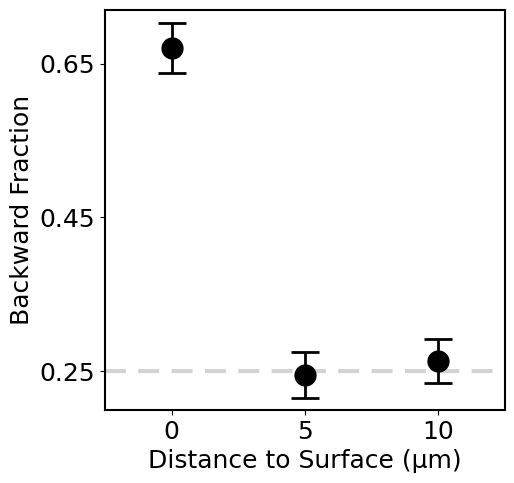

In [18]:
# plot backward fraction vs. distance
color = 'k'
# calculate fraction of backward (1 - forward_N/total_N)
fraction_backward = np.array(WT_backward_N) / np.array(WT_total_N)
# SE of proportion (standard error of the proportion)
se_proportion = np.sqrt((fraction_backward * (1 - fraction_backward)) / np.array(WT_total_N))
plt.figure(figsize=(5, 3.5))
plt.errorbar(WT_distance, fraction_backward, yerr=se_proportion, fmt='o', color=color, capsize=10, capthick=2, elinewidth=2, label='Open Space', markersize=15)

# fraction_backward_nopili = np.array(nopili_backward_N) / np.array(nopili_total_N)
# se_proportion_nopili = np.sqrt((fraction_backward_nopili * (1 - fraction_backward_nopili)) / np.array(nopili_total_N))
# plt.errorbar(nopili_distance, fraction_backward_nopili, yerr=se_proportion_nopili, fmt='o', color='red', capsize=5, capthick=1, elinewidth=1, label='nopili')

# fraction_backward_with_capsule = np.array(WT_with_capsule_backward_N) / np.array(WT_with_capsule_total_N)
# se_proportion_with_capsule = np.sqrt((fraction_backward_with_capsule * (1 - fraction_backward_with_capsule)) / np.array(WT_with_capsule_total_N))
# plt.errorbar(WT_with_capsule_distance, fraction_backward_with_capsule, yerr=se_proportion_with_capsule, fmt='o', color='blue', capsize=5, capthick=1, elinewidth=1, label='Outside µ-Trap')


# x ticks
plt.xticks(WT_distance, ['0', '5', '10'])

# legend
# plt.legend(loc='upper right', fontsize=12, frameon=False)

# labels
plt.xlabel('Distance to Surface (µm)', fontsize=12)
plt.ylabel('Backward Fraction', fontsize=12)

# ylim
# plt.ylim(0, 1)
# plt.ylim(0, 0.85)
plt.ylim(0.2, 0.72)
plt.xlim(-2.5, 12.5)
# add a dased line at 0.25
plt.axhline(y=0.25, color='lightgray', linestyle='--', linewidth=3, zorder=0, dashes=(5, 3))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=8)
# set yticks
# ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticks([0.25, 0.45, 0.65])

# # ---inset---
# # Create inset axes
# inset_ax = plt.axes([0.21, 0.17, 0.25, 0.25])  # [left, bottom, width, height]
# # Plot the inset data (5um)
# inset_ax.errorbar(WT_with_capsule_distance, fraction_backward_with_capsule, yerr=se_proportion_with_capsule, fmt='o', color='blue', capsize=5, capthick=1, elinewidth=1)
# inset_ax.errorbar(WT_distance, fraction_backward, yerr=se_proportion, fmt='o', color=color, capsize=5, capthick=1, elinewidth=1)
# # xlim and ylim for inset
# inset_ax.set_xlim(4.5, 5.5)  # Set x limits for the inset
# inset_ax.set_ylim(0.2, 0.4)  # Set y limits for the inset
# # set ticks
# inset_ax.set_yticks([0.25,  0.35])
# inset_ax.set_xticks([5])

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

set_size(4, 4)
# Set x and y limits for the inset
## Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('surface_response_v4.7.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
